# **Data cleaning and preparation**

---



## Card data

### Library and card data import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

pd.options.display.float_format = '{:.2f}'.format

In [2]:
card_url = 'https://drive.google.com/file/d/1XWbRb5j-qvuaj3rpfhahIE0YojWfYANl/view?usp=sharing'
card_trick = 'https://drive.google.com/uc?id=' + card_url.split('/')[-2]
card = pd.read_csv(card_trick)
card

,id,client_id,card_brand,card_number,expires,cvv,credit_limit,acct_open_date,year_pin_last_changed,days_since_last_trx,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
0,0,1362,Amex,393314135668401,04/2030,866,Rp53.189.000,01/1996,2019,17,181.00,Rp177.057.300,NaN,NaN
1,1,550,Mastercard,5278231764792292,06/2030,396,Rp18.200.000,01/1999,2018,27,148.00,Rp135.687.100,NaN,NaN
2,2,556,Mastercard,5889825928297675,09/2027,422,Rp31.298.000,01/2000,2016,20,415.00,Rp186.723.300,NaN,NaN
3,3,1937,Visa,4289888672554714,04/2026,736,Rp25.732.000,01/2000,2020,7,148.00,Rp207.881.500,NaN,NaN
4,4,1981,Mastercard,5433366978583845,03/2030,530,Rp30.500.000,01/2002,2012,14,48.00,Rp28.007.500,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5594,4508,1190,Visa,4227482000380763,07/2028,795,Rp7.301.000,09/2005,2012,5,320.00,Rp196.255.900,NaN,NaN
5595,209,1334,Visa,4144931322114018,02/2029,312,Rp14.592.000,01/2014,2014,32,41.00,Rp51.009.700,NaN,NaN
5596,2711,185,Visa,4718517475996018,01/2027,492,Rp8.943.000,04/2017,2017,14,198.00,Rp89.850.000,NaN,NaN
5597,1161,1891,Visa,4268017872699469,08/2031,476,Rp23.891.000,02/2013,2020,12,96.00,Rp43.768.500,NaN,NaN


A copy of the dataframe is created before proceeding with operations and manipulations. The initial dataframe overview is printed to help keep track of changes.

In [3]:
card_df = card.copy()
card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      5599 non-null   int64  
 1   client_id               5599 non-null   int64  
 2   card_brand              5599 non-null   object 
 3   card_number             5599 non-null   int64  
 4   expires                 5599 non-null   object 
 5   cvv                     5599 non-null   int64  
 6   credit_limit            5587 non-null   object 
 7   acct_open_date          5599 non-null   object 
 8   year_pin_last_changed   5599 non-null   int64  
 9   days_since_last_trx     5599 non-null   int64  
 10  count_nonfraud_trx_L6M  3707 non-null   float64
 11  amt_nonfraud_trx_L6M    3707 non-null   object 
 12  count_fraud_trx_L6M     547 non-null    float64
 13  amt_fraud_trx_L6M       547 non-null    object 
dtypes: float64(2), int64(6), object(6)
memor

### Data type conversion

Identifier columns are converted to `string`, while the categorical column is converted to `category`.

In [4]:
card_df[['id', 'client_id', 'card_number', 'cvv']] = (
    card_df[['id', 'client_id', 'card_number', 'cvv']]
    .astype('string')
)

In [5]:
card_df['card_brand'] = card_df['card_brand'].astype('category')

Columns with count values are converted to `Int64`.

In [6]:
card_df[['count_nonfraud_trx_L6M', 'count_fraud_trx_L6M', 'year_pin_last_changed', 'days_since_last_trx']] = (
    card_df[['count_nonfraud_trx_L6M', 'count_fraud_trx_L6M', 'year_pin_last_changed', 'days_since_last_trx']]
    .astype('Int64')
)

Columns containing date formats are converted to `datetime`.

In [7]:
card_df['expires'] = pd.to_datetime(
    card_df['expires'],
    format = '%m/%Y'
)
card_df['acct_open_date'] = pd.to_datetime(
    card_df['acct_open_date'],
    format = '%m/%Y'
)
card_df['year_pin_last_changed'] = pd.to_datetime(
    card_df['year_pin_last_changed'],
    format = '%Y'
)

Before converting columns with monetary values to `float`, all non-numerical symbols ("Rp" and ".") need to be removed.

In [8]:
money_columns = ['credit_limit', 'amt_nonfraud_trx_L6M', 'amt_fraud_trx_L6M']
for columns in money_columns:
    card_df[columns] = (
        card_df[columns]
        .astype('string')
        .str.replace('Rp', '', regex = False)
        .str.replace('.', '', regex = False)
        .str.strip()
    )
    card_df[columns] = pd.to_numeric(card_df[columns]).astype(float)

Sanity check to ensure that the codes are working as intended.

In [9]:
card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5599 non-null   string        
 1   client_id               5599 non-null   string        
 2   card_brand              5599 non-null   category      
 3   card_number             5599 non-null   string        
 4   expires                 5599 non-null   datetime64[ns]
 5   cvv                     5599 non-null   string        
 6   credit_limit            5587 non-null   float64       
 7   acct_open_date          5599 non-null   datetime64[ns]
 8   year_pin_last_changed   5599 non-null   datetime64[ns]
 9   days_since_last_trx     5599 non-null   Int64         
 10  count_nonfraud_trx_L6M  3707 non-null   Int64         
 11  amt_nonfraud_trx_L6M    3707 non-null   float64       
 12  count_fraud_trx_L6M     547 non-null    Int64   

### Typo fixes

Listing all the unique values for `card_brand`, which is a column with categorical values. Some typos can be seen here.

In [10]:
card_df['card_brand'].unique().tolist()

['Amex', 'Mastercard', 'Visa', 'JCB', 'Visa ', 'Jcb']

In [11]:
card_df['card_brand'].value_counts()

,count
card_brand,
Mastercard,2826
Visa,2093
Amex,402
JCB,206
Visa,69
Jcb,3


After checking with the data dictionary to ensure the correct values, a mapping is created to help replace each typo with the correct spelling.

In [12]:
card_brand_mapping = {
    'Visa ': 'Visa',
    'Jcb': 'JCB'
}

card_df['card_brand'] = card_df['card_brand'].replace(card_brand_mapping)
card_df['card_brand'].unique().tolist()

/tmp/ipython-input-229684205.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  card_df['card_brand'] = card_df['card_brand'].replace(card_brand_mapping)


['Amex', 'Mastercard', 'Visa', 'JCB']

In [13]:
card_df['card_brand'].value_counts()

,count
card_brand,
Mastercard,2826
Visa,2162
Amex,402
JCB,209


### Dropping duplicates, expired cards, and 0 credit limit cards

Checking for the amount of duplicates in the dataframe, and then dropping them.

In [14]:
card_df.duplicated().sum()

np.int64(31)

In [15]:
card_df = card_df.drop_duplicates()

Defining 31 May 2025 as the cut-off date to determine card expiry (according to the brief) and then filtering out cards that are already expired and have 0 credit limit. Last sanity check afterwards.

In [16]:
as_of_date = pd.Timestamp('2025-05-31')
card_df = card_df[
    (card_df['expires'] >= as_of_date) &
    (card_df['credit_limit'] > 0)
]

card_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5528 entries, 0 to 5567
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5528 non-null   string        
 1   client_id               5528 non-null   string        
 2   card_brand              5528 non-null   category      
 3   card_number             5528 non-null   string        
 4   expires                 5528 non-null   datetime64[ns]
 5   cvv                     5528 non-null   string        
 6   credit_limit            5528 non-null   float64       
 7   acct_open_date          5528 non-null   datetime64[ns]
 8   year_pin_last_changed   5528 non-null   datetime64[ns]
 9   days_since_last_trx     5528 non-null   Int64         
 10  count_nonfraud_trx_L6M  3680 non-null   Int64         
 11  amt_nonfraud_trx_L6M    3680 non-null   float64       
 12  count_fraud_trx_L6M     547 non-null    Int64        

## User data

### User data import

In [17]:
user_url = 'https://drive.google.com/file/d/1_xFUfSyvA3jgTBELM38KYo-7H2AIEO6y/view?usp=sharing'
user_trick = 'https://drive.google.com/uc?id=' + user_url.split('/')[-2]
user = pd.read_csv(user_trick)
user

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score
0,825,66,1972-11-25,Female,Rp45.937.000,Rp93.663.000,Rp38.138.095,787
1,1746,68,1972-12-16,Female,Rp59.451.000,Rp121.212.000,Rp57.186.095,701
2,1718,67,1944-11-04,Female,Rp35.586.000,Rp52.535.000,Rp58.666,698
3,708,63,1963-01-12,Female,Rp255.975.000,Rp392.132.000,Rp60.467.238,722
4,1164,70,1982-09-21,Male,Rp84.407.000,Rp172.099.000,Rp54.946.285,675
...,...,...,...,...,...,...,...,...
1995,986,70,1993-07-06,Male,Rp36.950.000,Rp75.328.000,Rp26.250.666,703
1996,1944,65,1963-11-12,Female,Rp37.998.000,Rp77.474.000,Rp31.224.571,740
1997,185,67,1979-01-30,Female,Rp23.810.000,Rp48.548.000,Rp21.238.666,779
1998,1007,60,1960-02-23,Male,Rp39.752.000,Rp85.752.000,Rp8.141.142,618


Creating a copy of the dataframe and checking the initial overview.

In [18]:
user_df = user.copy()
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 2000 non-null   int64 
 1   retirement_age     2000 non-null   int64 
 2   birthdate          2000 non-null   object
 3   gender             2000 non-null   object
 4   per_capita_income  2000 non-null   object
 5   yearly_income      2000 non-null   object
 6   total_debt         2000 non-null   object
 7   credit_score       2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


### Data type conversion

Identifier column is converted to `string`, while the categorical column is converted to `category`.

In [19]:
user_df['id'] = user_df['id'].astype('string')

In [20]:
user_df['gender'] = user_df['gender'].astype('category')

Columns with count values are converted to `Int64`.

In [21]:
user_df[['retirement_age', 'credit_score']] = (
    user_df[['retirement_age', 'credit_score']]
    .astype('Int64')
)

The date format column is converted to `datetime`.

In [22]:
user_df['birthdate'] = pd.to_datetime(
    user_df['birthdate'],
    format = '%Y-%m-%d'
)

Removing non-numerical symbols from columns with monetary values, then converting them to `float`.

In [23]:
money_columns = ['per_capita_income', 'yearly_income', 'total_debt']
for columns in money_columns:
    user_df[columns] = (
        user_df[columns]
        .astype('string')
        .str.replace('Rp', '', regex = False)
        .str.replace('.', '', regex = False)
        .str.strip()
    )
    user_df[columns] = pd.to_numeric(user_df[columns]).astype(float)

Sanity check.

In [24]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 2000 non-null   string        
 1   retirement_age     2000 non-null   Int64         
 2   birthdate          2000 non-null   datetime64[ns]
 3   gender             2000 non-null   category      
 4   per_capita_income  2000 non-null   float64       
 5   yearly_income      2000 non-null   float64       
 6   total_debt         2000 non-null   float64       
 7   credit_score       2000 non-null   Int64         
dtypes: Int64(2), category(1), datetime64[ns](1), float64(3), string(1)
memory usage: 115.5 KB


### Inserting `age`, `retired_flag`, and `dti` columns

Creating `age` column, using the `as_of_date` variable that has been defined earlier and `birthdate` to calculate the age.

In [25]:
def calc_age(birthdate, as_of):
    years = as_of.year - birthdate.dt.year
    birthday_month_not_reached = as_of.month < birthdate.dt.month
    birthday_day_not_reached = (
        (as_of.month == birthdate.dt.month) &
        (as_of.day < birthdate.dt.day)
    )
    birthday_not_passed = (
        birthday_month_not_reached | birthday_day_not_reached
    )
    return years - birthday_not_passed
user_df['age'] = calc_age(user_df['birthdate'], as_of_date).astype('Int64')

Creating `retired_flage` column, checking the `age` with the `retirement_age` to determine retirement status, which returns boolean values.

In [26]:
user_df['retired_flag'] = (user_df['age'] >= user_df['retirement_age'])

Making sure that there are no negative `yearly_income` values before calculating DTI ratio.

In [27]:
(user_df['yearly_income'] <= 0).sum()

np.int64(0)

Creating `dti` column that calculates the ratio of `total_debt` to `yearly_income`.

In [28]:
user_df['dti'] = user_df['total_debt'] / user_df['yearly_income']

Last sanity check.

In [29]:
user_df

,id,retirement_age,birthdate,gender,per_capita_income,yearly_income,total_debt,credit_score,age,retired_flag,dti
0,825,66,1972-11-25,Female,45937000.00,93663000.00,38138095.00,787,52,False,0.41
1,1746,68,1972-12-16,Female,59451000.00,121212000.00,57186095.00,701,52,False,0.47
2,1718,67,1944-11-04,Female,35586000.00,52535000.00,58666.00,698,80,True,0.00
3,708,63,1963-01-12,Female,255975000.00,392132000.00,60467238.00,722,62,False,0.15
4,1164,70,1982-09-21,Male,84407000.00,172099000.00,54946285.00,675,42,False,0.32
...,...,...,...,...,...,...,...,...,...,...,...
1995,986,70,1993-07-06,Male,36950000.00,75328000.00,26250666.00,703,31,False,0.35
1996,1944,65,1963-11-12,Female,37998000.00,77474000.00,31224571.00,740,61,False,0.40
1997,185,67,1979-01-30,Female,23810000.00,48548000.00,21238666.00,779,46,False,0.44
1998,1007,60,1960-02-23,Male,39752000.00,85752000.00,8141142.00,618,65,True,0.09


In [30]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 2000 non-null   string        
 1   retirement_age     2000 non-null   Int64         
 2   birthdate          2000 non-null   datetime64[ns]
 3   gender             2000 non-null   category      
 4   per_capita_income  2000 non-null   float64       
 5   yearly_income      2000 non-null   float64       
 6   total_debt         2000 non-null   float64       
 7   credit_score       2000 non-null   Int64         
 8   age                2000 non-null   Int64         
 9   retired_flag       2000 non-null   boolean       
 10  dti                2000 non-null   float64       
dtypes: Int64(3), boolean(1), category(1), datetime64[ns](1), float64(4), string(1)
memory usage: 152.6 KB




---



# **Exploratory Data Analysis**

---



## Descriptive analytics

Data overview before doing EDA.

In [31]:
card_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5528 entries, 0 to 5567
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      5528 non-null   string        
 1   client_id               5528 non-null   string        
 2   card_brand              5528 non-null   category      
 3   card_number             5528 non-null   string        
 4   expires                 5528 non-null   datetime64[ns]
 5   cvv                     5528 non-null   string        
 6   credit_limit            5528 non-null   float64       
 7   acct_open_date          5528 non-null   datetime64[ns]
 8   year_pin_last_changed   5528 non-null   datetime64[ns]
 9   days_since_last_trx     5528 non-null   Int64         
 10  count_nonfraud_trx_L6M  3680 non-null   Int64         
 11  amt_nonfraud_trx_L6M    3680 non-null   float64       
 12  count_fraud_trx_L6M     547 non-null    Int64        

In [32]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 2000 non-null   string        
 1   retirement_age     2000 non-null   Int64         
 2   birthdate          2000 non-null   datetime64[ns]
 3   gender             2000 non-null   category      
 4   per_capita_income  2000 non-null   float64       
 5   yearly_income      2000 non-null   float64       
 6   total_debt         2000 non-null   float64       
 7   credit_score       2000 non-null   Int64         
 8   age                2000 non-null   Int64         
 9   retired_flag       2000 non-null   boolean       
 10  dti                2000 non-null   float64       
dtypes: Int64(3), boolean(1), category(1), datetime64[ns](1), float64(4), string(1)
memory usage: 152.6 KB


### Total net profit calculation

With a Merchant Discount Rate (MDR) of 1.5%, net profit can be calculated from `mdr_profit - total_fraud_amt`.

In [33]:
total_nonfraud_amt = card_df['amt_nonfraud_trx_L6M'].sum()
mdr_rate = 0.015
mdr_profit = mdr_rate * total_nonfraud_amt
total_fraud_amt = card_df['amt_fraud_trx_L6M'].sum()
net_profit = mdr_profit - total_fraud_amt

print(
    f'Total non-fraud amount: {total_nonfraud_amt:.2f}\n'
    f'MDR profit (1.5%): {mdr_profit:.2f}\n'
    f'Total fraud amount: {total_fraud_amt:.2f}'
)
print()
print(f'Total net profit: {net_profit:.2f}')

Total non-fraud amount: 455863486600.00
MDR profit (1.5%): 6837952299.00
Total fraud amount: 1013378300.00

Total net profit: 5824573999.00


### Fraud rate calculation

Fraud rate is the result of dividing total fraud amount by overall income (total fraud amount + total non-fraud amount)

In [34]:
fraud_rate = total_fraud_amt / (total_fraud_amt + total_nonfraud_amt)
print(f'Fraud rate: {fraud_rate:.2%}')

Fraud rate: 0.22%


Creating a pie chart as the visualization of fraud vs non-fraud amount.

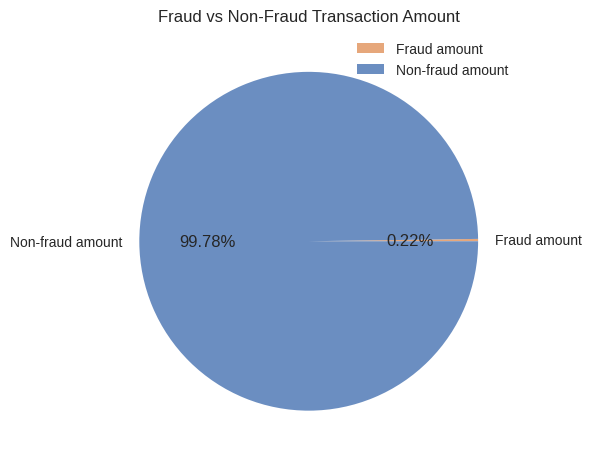

In [35]:
labels = ['Fraud amount', 'Non-fraud amount']
values = [total_fraud_amt, total_nonfraud_amt]
colors = ['#e6a77b', '#6b8ec1']

plt.figure()
plt.pie(
    values,
    labels = labels,
    colors = colors,
    autopct = '%1.2f%%'
)

plt.legend()
plt.title('Fraud vs Non-Fraud Transaction Amount')
plt.show()

### Transaction behavior per card brand

Creating `card_brand_summary` to store the average of non-fraud count and amount grouped by `card_brand`.

In [36]:
card_brand_summary = (
    card_df
    .groupby('card_brand')
    .agg(
        avg_nonfraud_count = ('count_nonfraud_trx_L6M', 'mean'),
        avg_nonfraud_amt = ('amt_nonfraud_trx_L6M', 'mean')
    )
    .reset_index()
)

card_brand_summary

/tmp/ipython-input-4156759669.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('card_brand')


,card_brand,avg_nonfraud_count,avg_nonfraud_amt
0,Amex,170.49,149226362.45
1,JCB,125.37,111451840.58
2,Mastercard,182.93,120915253.97
3,Visa,174.66,124337802.84


Creating a bar chart to visualize the average transaction count for each card brand.

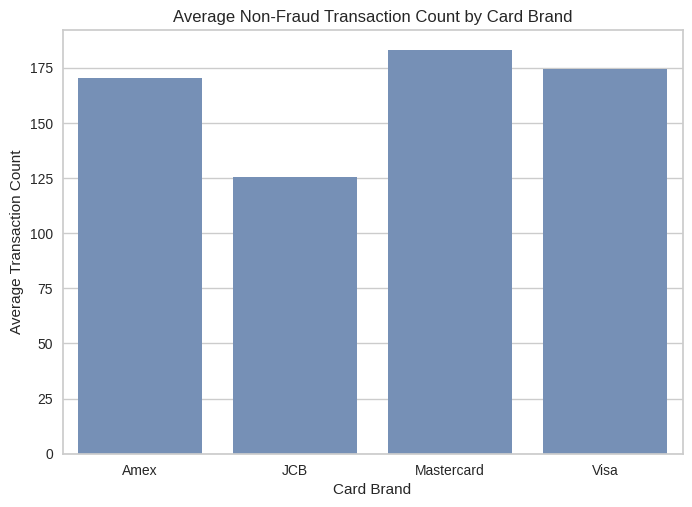

In [37]:
plt.figure()
sns.barplot(
    data = card_brand_summary,
    x = 'card_brand',
    y = 'avg_nonfraud_count',
    color = '#6b8ec1'
)

plt.title('Average Non-Fraud Transaction Count by Card Brand')
plt.xlabel('Card Brand')
plt.ylabel('Average Transaction Count')
plt.show()

Creating a bar chart to visualize the average transaction amount for each card brand. Y-axis is set to show the amount in millions.

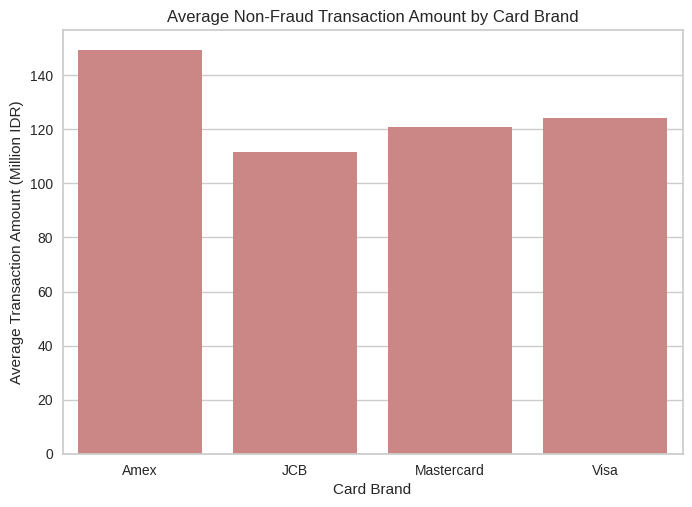

In [38]:
plt.figure()
sns.barplot(
    data = card_brand_summary,
    x = 'card_brand',
    y = card_brand_summary['avg_nonfraud_amt'] / 1_000_000,
    color = '#d77a7a'
)

plt.title('Average Non-Fraud Transaction Amount by Card Brand')
plt.xlabel('Card Brand')
plt.ylabel('Average Transaction Amount (Million IDR)')
plt.show()

### Retired vs non-retired DTI

Creating `dti_summary` to show the average, median, min, and max of DTI grouped by `retired_flag`.

In [39]:
dti_summary = (
    user_df
    .groupby('retired_flag')
    .agg(
        avg_dti = ('dti', 'mean'),
        median_dti = ('dti', 'median'),
        min_dti = ('dti', 'min'),
        max_dti = ('dti', 'max')
    )
    .reset_index()
)

dti_summary

,retired_flag,avg_dti,median_dti,min_dti,max_dti
0,False,0.30,0.30,0.00,0.95
1,True,0.07,0.04,0.00,0.42


Creating boxplots of DTI grouped by non-retired and retired.

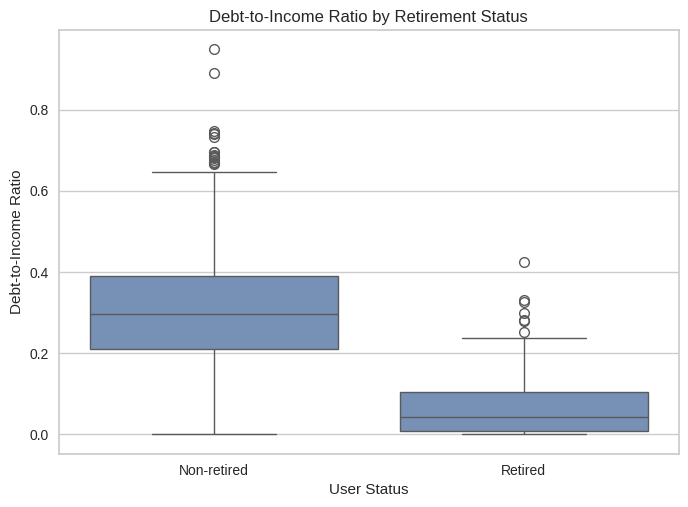

In [40]:
plt.figure()
sns.boxplot(
    x = 'retired_flag',
    y = 'dti',
    data = user_df,
    color = '#6b8ec1'
)

plt.xticks([0,1], ['Non-retired', 'Retired'])
plt.title('Debt-to-Income Ratio by Retirement Status')
plt.xlabel('User Status')
plt.ylabel('Debt-to-Income Ratio')
plt.show()

## Additional insights

Merging `card_df` and `user_df` on `client_id` and `id`.

In [41]:
merged_df = card_df.merge(
    user_df,
    how = 'left',
    left_on = 'client_id',
    right_on = 'id'
)

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5528 entries, 0 to 5527
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_x                    5528 non-null   string        
 1   client_id               5528 non-null   string        
 2   card_brand              5528 non-null   category      
 3   card_number             5528 non-null   string        
 4   expires                 5528 non-null   datetime64[ns]
 5   cvv                     5528 non-null   string        
 6   credit_limit            5528 non-null   float64       
 7   acct_open_date          5528 non-null   datetime64[ns]
 8   year_pin_last_changed   5528 non-null   datetime64[ns]
 9   days_since_last_trx     5528 non-null   Int64         
 10  count_nonfraud_trx_L6M  3680 non-null   Int64         
 11  amt_nonfraud_trx_L6M    3680 non-null   float64       
 12  count_fraud_trx_L6M     547 non-null    Int64   

Checking the number of unique users, since some users may not have a card. This number should match the number of rows after the data is grouped by `client_id`.

In [42]:
merged_df["client_id"].nunique()

1938

Grouping data by `client_id`, since one user may have more than one cards. Irrelevant columns are not included.

In [43]:
recency = 'days_since_last_trx'
user_columns = ['age', 'retired_flag', 'credit_score', 'dti']
count_columns = ['count_nonfraud_trx_L6M', 'count_fraud_trx_L6M']
money_columns = ['credit_limit', 'amt_nonfraud_trx_L6M', 'amt_fraud_trx_L6M']

In [44]:
agg_dictionary = {recency: 'min'}
agg_dictionary.update({col: 'first' for col in user_columns})
agg_dictionary.update({col:'sum' for col in count_columns + money_columns})

After grouping, the number of rows should represent the number of unique users in `agg_df`, which matches with `merged_df`.

In [45]:
agg_df = merged_df.groupby('client_id').agg(agg_dictionary).reset_index()
agg_df

,client_id,days_since_last_trx,age,retired_flag,credit_score,dti,count_nonfraud_trx_L6M,count_fraud_trx_L6M,credit_limit,amt_nonfraud_trx_L6M,amt_fraud_trx_L6M
0,0,3,33,False,763,0.12,685,0,165775000.00,535262100.00,0.00
1,1,20,43,False,704,0.06,498,0,65592000.00,264007900.00,0.00
2,10,604,29,False,727,0.30,0,0,108249000.00,0.00,0.00
3,100,5,55,False,813,0.31,366,0,236386000.00,295701900.00,0.00
4,1000,604,19,False,687,0.32,0,0,36225000.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...
1933,995,604,40,False,592,0.58,0,0,29963000.00,0.00,0.00
1934,996,0,62,False,738,0.51,871,2,154043000.00,570563000.00,6509000.00
1935,997,2,56,False,675,0.37,1178,0,53660000.00,674910900.00,0.00
1936,998,604,17,False,703,0.13,0,0,32579000.00,0.00,0.00


### Credit score category

The users are grouped into 5 categories based on their credit score. The categories are created according to the assignment brief. A new `credit_score_category` column is added.

In [46]:
bins = [300, 579, 669, 739, 799, 850]
labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']

agg_df['credit_score_category'] = pd.cut(
    agg_df['credit_score'],
    bins = bins,
    labels = labels,
    right = True
)

agg_df

,client_id,days_since_last_trx,age,retired_flag,credit_score,dti,count_nonfraud_trx_L6M,count_fraud_trx_L6M,credit_limit,amt_nonfraud_trx_L6M,amt_fraud_trx_L6M,credit_score_category
0,0,3,33,False,763,0.12,685,0,165775000.00,535262100.00,0.00,Very Good
1,1,20,43,False,704,0.06,498,0,65592000.00,264007900.00,0.00,Good
2,10,604,29,False,727,0.30,0,0,108249000.00,0.00,0.00,Good
3,100,5,55,False,813,0.31,366,0,236386000.00,295701900.00,0.00,Exceptional
4,1000,604,19,False,687,0.32,0,0,36225000.00,0.00,0.00,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,604,40,False,592,0.58,0,0,29963000.00,0.00,0.00,Fair
1934,996,0,62,False,738,0.51,871,2,154043000.00,570563000.00,6509000.00,Good
1935,997,2,56,False,675,0.37,1178,0,53660000.00,674910900.00,0.00,Good
1936,998,604,17,False,703,0.13,0,0,32579000.00,0.00,0.00,Good


Calculating the average of DTI for each credit score category.

In [47]:
dti_per_category = agg_df.groupby('credit_score_category')['dti'].mean().reset_index()
dti_per_category

/tmp/ipython-input-1950336387.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_per_category = agg_df.groupby('credit_score_category')['dti'].mean().reset_index()


,credit_score_category,dti
0,Poor,0.30
1,Fair,0.32
2,Good,0.25
3,Very Good,0.25
4,Exceptional,0.24


Calculating the average of transaction count and amount for each credit score category.

In [48]:
trx_per_category = agg_df.groupby('credit_score_category').agg({
    'count_nonfraud_trx_L6M': 'mean',
    'amt_nonfraud_trx_L6M': 'mean'
}).reset_index()
trx_per_category

/tmp/ipython-input-3277171170.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trx_per_category = agg_df.groupby('credit_score_category').agg({


,credit_score_category,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M
0,Poor,305.48,229026451.95
1,Fair,287.60,201948543.25
2,Good,337.05,241935115.77
3,Very Good,366.56,247826670.65
4,Exceptional,350.30,231519725.31


The `dti_per_category` and `trx_per_category` tables are merged into `category_summary` for convenience.

In [49]:
category_summary = dti_per_category.merge(trx_per_category, on = 'credit_score_category')

Creating a bar chart to visualize the transaction amount average and a line chart to visualize the DTI average for each credit score category. To make it easier to see the relationship between average transaction amount and DTI, the charts are stacked on top of each other.

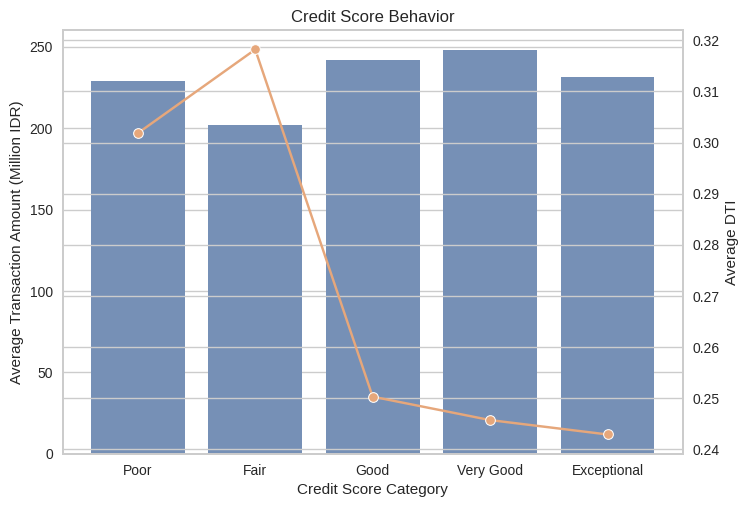

In [50]:
fig, ax1 = plt.subplots()

sns.barplot(
    x = category_summary['credit_score_category'],
    y = category_summary['amt_nonfraud_trx_L6M'] / 1_000_000,
    ax = ax1,
    color = '#6b8ec1'
)
ax1.set_xlabel('Credit Score Category')
ax1.set_ylabel('Average Transaction Amount (Million IDR)')

ax2 = ax1.twinx()
sns.lineplot(
    data = category_summary,
    x = 'credit_score_category',
    y = 'dti',
    marker = 'o',
    color = '#e6a77b',
    ax = ax2
)
ax2.set_ylabel('Average DTI')

plt.title('Credit Score Behavior')
plt.show()

### Age and credit limit

The age distribution is checked to see if the age range needs to be trimmed to prevent small and volatile data.

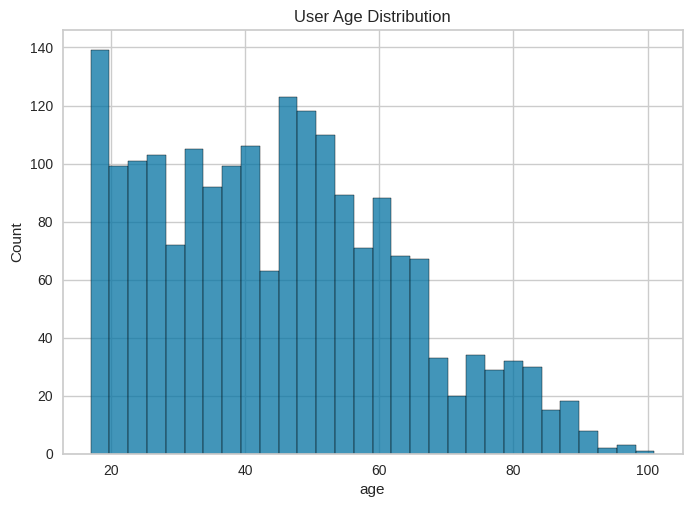

In [51]:
sns.histplot(agg_df["age"], bins=30)
plt.title("User Age Distribution")
plt.show()

There is a significant drop in count for ages 70 and up, so it is filtered out.

In [52]:
age_filter = agg_df[agg_df['age'] <= 70]

age_summary = (
    age_filter
    .groupby('age')
    .agg(
        total_credit_limit = ('credit_limit', 'sum'),
        user_count = ('client_id', 'count')
    )
    .reset_index()
)
age_summary['avg_credit_limit'] = (
    age_summary['total_credit_limit'] /
    age_summary['user_count']
)

Creating a line chart to visualize the relationship between average credit limit (in million IDR) and age.

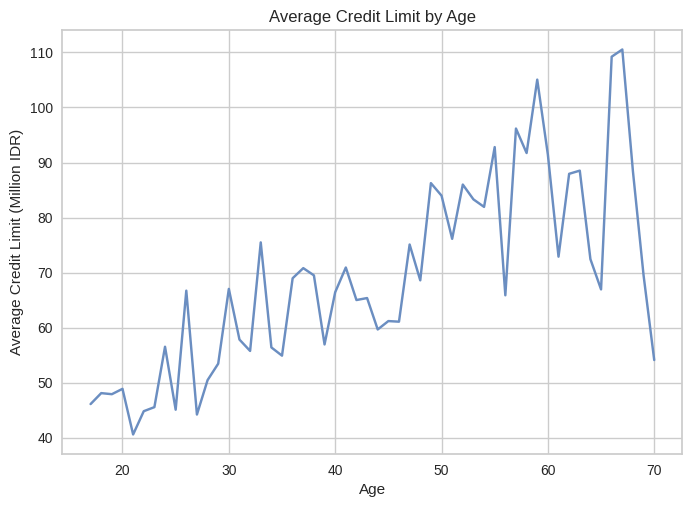

In [53]:
plt.figure()
sns.lineplot(
    x = age_summary['age'],
    y = age_summary['avg_credit_limit'] / 1_000_000,
    color = '#6b8ec1'
)

plt.title('Average Credit Limit by Age')
plt.xlabel('Age')
plt.ylabel('Average Credit Limit (Million IDR)')
plt.show()

---

# **Customer Segmentation**


---



## Clustering preparation

Data overview before clustering.

In [54]:
agg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   client_id               1938 non-null   string  
 1   days_since_last_trx     1938 non-null   Int64   
 2   age                     1938 non-null   Int64   
 3   retired_flag            1938 non-null   boolean 
 4   credit_score            1938 non-null   Int64   
 5   dti                     1938 non-null   float64 
 6   count_nonfraud_trx_L6M  1938 non-null   Int64   
 7   count_fraud_trx_L6M     1938 non-null   Int64   
 8   credit_limit            1938 non-null   float64 
 9   amt_nonfraud_trx_L6M    1938 non-null   float64 
 10  amt_fraud_trx_L6M       1938 non-null   float64 
 11  credit_score_category   1938 non-null   category
dtypes: Int64(5), boolean(1), category(1), float64(4), string(1)
memory usage: 166.9 KB


To ensure that customer segments are formed based on meaningful behavioral, financial, and risk-related attributes, these features are selected for clustering:
*   `count_nonfraud_trx_L6M`
*   `amt_nonfraud_trx_L6M`
*   `recency`
*   `credit_limit`
*   `dti`

In [55]:
cluster_features = [
    'count_nonfraud_trx_L6M',
    'amt_nonfraud_trx_L6M',
    'days_since_last_trx',
    'credit_limit',
    'dti',
]

X = agg_df[cluster_features]

## Standardizing features

StandardScaler is used to normalize feature scales while preserving relative distances between observations.

In [56]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = cluster_features)
X_scaled

,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,days_since_last_trx,credit_limit,dti
0,0.99,1.12,-0.81,1.49,-0.88
1,0.46,0.11,-0.75,-0.09,-1.21
2,-0.96,-0.88,1.27,0.58,0.26
3,0.09,0.23,-0.80,2.61,0.30
4,-0.96,-0.88,1.27,-0.55,0.37
...,...,...,...,...,...
1933,-0.96,-0.88,1.27,-0.65,1.90
1934,1.52,1.26,-0.82,1.31,1.50
1935,2.40,1.65,-0.81,-0.28,0.63
1936,-0.96,-0.88,1.27,-0.61,-0.78


## Elbow method

The elbow method is used to help identify which k is more optimal, identified at the point where the rate of decrease sharply slows.

In [57]:
inertia = []
k_range = range(2,11)

for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 7)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

elbow_df = pd.DataFrame({
    'k': k_range,
    'inertia': inertia
})

In this case, the more optimal k falls between 3, 4, and 5.

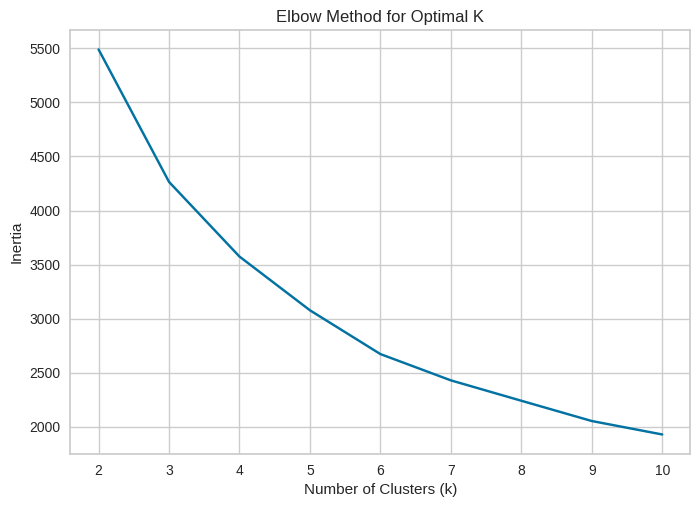

In [58]:
plt.figure()
sns.lineplot(
    data = elbow_df,
    x = 'k',
    y = 'inertia'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

## Silhouette score

To further ensure how optimal each k is, silhouette score is calculated and visualized into a silhouette plot. From the visualization, it can be seen that k = 3 is the most appropriate, with the highest average silhouette score and more well-separated clusters.

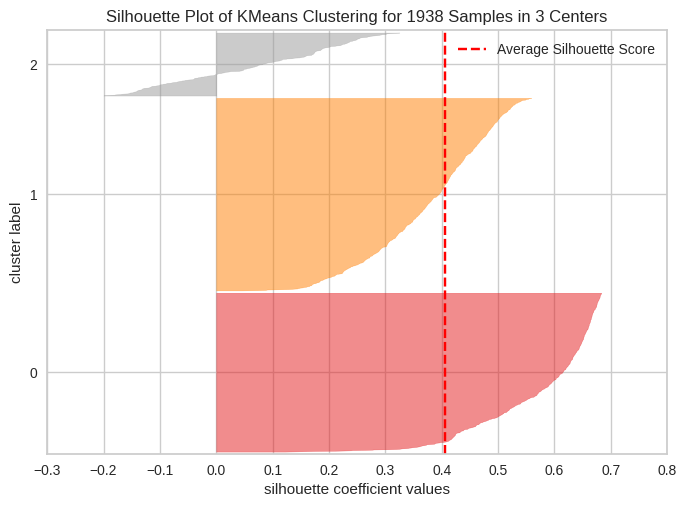

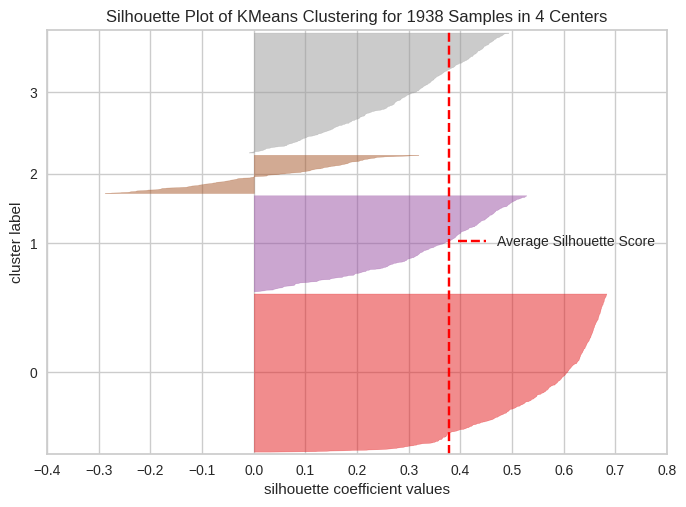

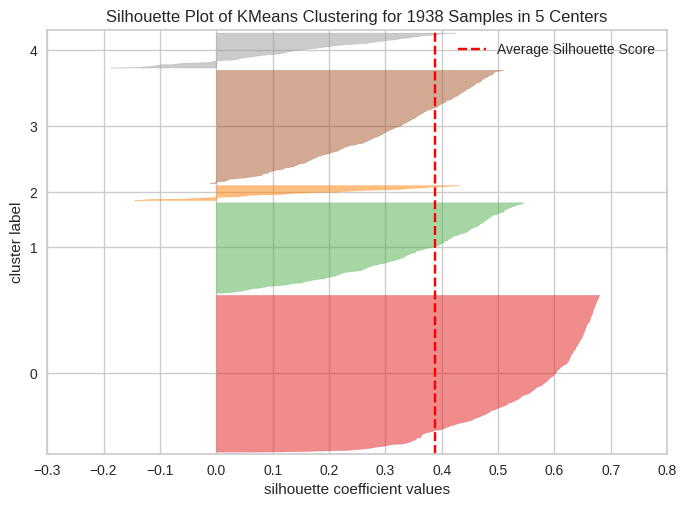

In [59]:
for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters = k, random_state = 7)
    SilhouetteVisualizer(kmeans).fit(X_scaled).show()

## K-Means clustering

K-Means Clustering is chosen as the clustering method because:
* Handles continuous behavioral variables
effectively
* Suitable for identifying distinct spending patterns
* More actionable than rule-based segmentation for this use case

The number of clusters is set to 3, with a `random_state` of 7 to ensure consistent clustering.

In [60]:
kmeans = KMeans(
    n_clusters = 3,
    random_state = 7,
    n_init = 'auto'
)

agg_df['cluster'] = kmeans.fit_predict(X_scaled)
agg_df

,client_id,days_since_last_trx,age,retired_flag,credit_score,dti,count_nonfraud_trx_L6M,count_fraud_trx_L6M,credit_limit,amt_nonfraud_trx_L6M,amt_fraud_trx_L6M,credit_score_category,cluster
0,0,3,33,False,763,0.12,685,0,165775000.00,535262100.00,0.00,Very Good,2
1,1,20,43,False,704,0.06,498,0,65592000.00,264007900.00,0.00,Good,1
2,10,604,29,False,727,0.30,0,0,108249000.00,0.00,0.00,Good,0
3,100,5,55,False,813,0.31,366,0,236386000.00,295701900.00,0.00,Exceptional,2
4,1000,604,19,False,687,0.32,0,0,36225000.00,0.00,0.00,Good,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1933,995,604,40,False,592,0.58,0,0,29963000.00,0.00,0.00,Fair,0
1934,996,0,62,False,738,0.51,871,2,154043000.00,570563000.00,6509000.00,Good,2
1935,997,2,56,False,675,0.37,1178,0,53660000.00,674910900.00,0.00,Good,2
1936,998,604,17,False,703,0.13,0,0,32579000.00,0.00,0.00,Good,0


## Cluster profiling

Cluster profiling aggregates key numerical features within each cluster to summarize behavioral and financial characteristics.

In [61]:
cluster_profile = (
    agg_df
    .groupby('cluster')
    .agg({
        'days_since_last_trx': 'mean',
        'age': 'mean',
        'credit_score': 'mean',
        'dti': 'mean',
        'credit_limit': 'mean',
        'count_nonfraud_trx_L6M': 'mean',
        'amt_nonfraud_trx_L6M': 'mean',
        'count_fraud_trx_L6M': 'mean',
        'amt_fraud_trx_L6M': 'mean'
    })
    .round(2)
)

cluster_profile

,days_since_last_trx,age,credit_score,dti,credit_limit,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M
cluster,,,,,,,,,
0,604.00,33.01,705.70,0.29,47027302.83,0.00,0.00,0.00,0.00
1,9.60,51.05,710.97,0.26,63510658.89,449.33,288062097.56,0.51,799189.44
2,6.99,56.34,720.73,0.19,155942396.61,833.81,666466436.61,0.66,996975.59


Cluster size analysis examines the number and proportion of users assigned to each cluster. This ensures that clusters are not overly imbalanced.

In [62]:
cluster_size = agg_df['cluster'].value_counts().sort_index()

cluster_profile['user_count'] = cluster_size
cluster_profile['user_percentage'] = (
    cluster_size / cluster_size.sum() * 100
).round(2)

cluster_profile

,days_since_last_trx,age,credit_score,dti,credit_limit,count_nonfraud_trx_L6M,amt_nonfraud_trx_L6M,count_fraud_trx_L6M,amt_fraud_trx_L6M,user_count,user_percentage
cluster,,,,,,,,,,,
0,604.00,33.01,705.70,0.29,47027302.83,0.00,0.00,0.00,0.00,743,38.34
1,9.60,51.05,710.97,0.26,63510658.89,449.33,288062097.56,0.51,799189.44,900,46.44
2,6.99,56.34,720.73,0.19,155942396.61,833.81,666466436.61,0.66,996975.59,295,15.22


The cluster profiles above are used to identify high-potential customer segments and derive business recommendations, which are presented in the accompanying slides.

---

